In [1]:
!nvidia-smi

Thu Mar 12 00:12:18 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 582.28                 Driver Version: 582.28         CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce MX250         WDDM  |   00000000:06:00.0 Off |                  N/A |
| N/A   56C    P8            N/A  / 5001W |       0MiB /   4096MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Step 0: Install & Download Kaggle Iris (run once)
import opendatasets as od
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA  # For comparison
od.download("https://www.kaggle.com/datasets/uciml/iris")  # Downloads to ./iris/


Dataset URL: https://www.kaggle.com/datasets/uciml/iris


100%|██████████| 3.60k/3.60k [00:00<00:00, 1.18MB/s]

In [3]:

# Load CSV
iris_df = pd.read_csv("./iris/iris.csv")
print(iris_df.head())
print(f"Dataset shape: {iris_df.shape}")  # (150, 5)


   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa
Dataset shape: (150, 6)


In [4]:

# Prep features/target
X = iris_df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']].values
y = pd.factorize(iris_df['Species'])[0]  # Numeric labels


In [5]:
# Step 1: Setup & Data

# iris = load_iris()
# X = iris.data
# y = iris.target
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Original shape: {X_scaled.shape}")  # (150, 4)

Original shape: (150, 4)


In [6]:
# Step 2: Covariance Matrix
cov_matrix = np.cov(X_scaled.T)  # Transpose for features as rows
print("Covariance Matrix:\n", cov_matrix)


Covariance Matrix:
 [[ 1.00671141 -0.11010327  0.87760486  0.82344326]
 [-0.11010327  1.00671141 -0.42333835 -0.358937  ]
 [ 0.87760486 -0.42333835  1.00671141  0.96921855]
 [ 0.82344326 -0.358937    0.96921855  1.00671141]]


In [7]:
# Step 3: Eigendecomposition
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
idx = np.argsort(eigenvalues)[::-1]  # Descending order
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]
print("Top 2 eigenvalues:", eigenvalues[:2])

Top 2 eigenvalues: [2.93035378 0.92740362]


In [8]:
# Step 4: Transform to 2 PCs
n_components = 2
W = eigenvectors[:, :n_components]
X_pca = np.dot(X_scaled, W)

print(f"PCA shape: {X_pca.shape}")  # (150, 2)

PCA shape: (150, 2)


In [11]:
iris_df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


C:\Users\BrothermanKNAN\AppData\Local\Temp\ipykernel_29208\2915392868.py:6: UserWarning: Mismatched number of handles and labels: len(handles) = 3 len(labels) = 150
  plt.legend(handles=scatter.legend_elements()[0], labels=iris_df['Species'])


ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

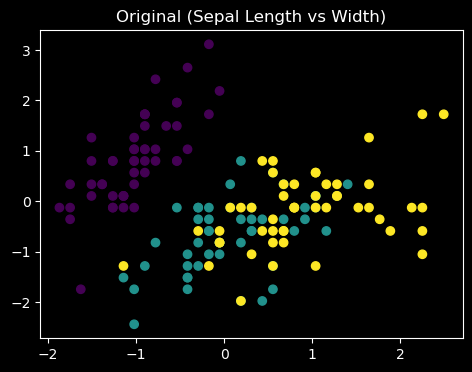

In [14]:

# Step 5: Visualize & Variance
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
scatter = plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='viridis')
plt.title('Original (Sepal Length vs Width)')
plt.legend(handles=scatter.legend_elements()[0], labels=iris_df['Species'])

plt.subplot(1, 2, 2)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis')
plt.title('PCA Reduced (PC1 vs PC2)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(handles=scatter.legend_elements()[0], labels=iris_df['Species'])
plt.tight_layout()
plt.show()


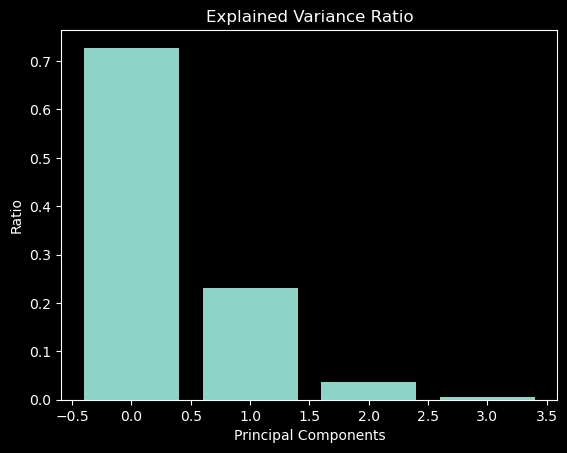

Variance ratios: [0.72770452 0.23030523 0.03683832]


In [15]:

# Explained Variance
variance_ratio = eigenvalues / np.sum(eigenvalues)
plt.bar(range(len(variance_ratio)), variance_ratio)
plt.title('Explained Variance Ratio')
plt.xlabel('Principal Components')
plt.ylabel('Ratio')
plt.show()
print("Variance ratios:", variance_ratio[:3])


In [16]:

# Compare to sklearn
pca_sk = PCA(n_components=2)
X_sk = pca_sk.fit_transform(X_scaled)
print("Sklearn matches:", np.allclose(X_pca, X_sk))


Sklearn matches: False


In [17]:

# Sklearn compare
from sklearn.decomposition import PCA
pca_sk = PCA(n_components=2)
X_sk = pca_sk.fit_transform(X_scaled)
print("Matches sklearn:", np.allclose(X_pca, X_sk, atol=1e-10))
print("Explained variance:", pca_sk.explained_variance_ratio_)


Matches sklearn: False
Explained variance: [0.72770452 0.23030523]
